# 1. Protests in the US

In [2]:
! pip install geopandas pandas matplotlib numpy plotly textwrap

ERROR: Could not find a version that satisfies the requirement textwrap (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for textwrap


In [3]:
import geopandas as gpd
import matplotlib.gridspec as gridspec
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches


In [4]:
raw_data = pd.read_excel(
    "conflict data/US-and-Canada_aggregated_data_up_to-2026-02-28.xlsx"
)

In [5]:
raw_data

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2022-04-09,North America,Bermuda,Devonshire,Protests,Peaceful protest,1,0,1882.0,Demonstrations,3888.0,32.3033,-64.7595
1,2021-05-01,North America,Bermuda,Pembroke,Protests,Peaceful protest,1,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896
2,2021-06-26,North America,Bermuda,Pembroke,Protests,Peaceful protest,1,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896
3,2021-08-28,North America,Bermuda,Pembroke,Protests,Peaceful protest,2,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896
4,2021-11-06,North America,Bermuda,Pembroke,Protests,Peaceful protest,1,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22184,2025-04-05,North America,United States,Wyoming,Strategic developments,Other,1,0,NaN,Strategic developments,3533.0,42.9879,-107.5485
22185,2025-04-19,North America,United States,Wyoming,Strategic developments,Other,1,0,NaN,Strategic developments,3533.0,42.9879,-107.5485
22186,2025-05-03,North America,United States,Wyoming,Strategic developments,Other,1,0,NaN,Strategic developments,3533.0,42.9879,-107.5485
22187,2025-10-04,North America,United States,Wyoming,Strategic developments,Other,1,0,NaN,Strategic developments,3533.0,42.9879,-107.5485


In [6]:
raw_data.loc[:, 'SUB_EVENT_TYPE'].value_counts()

SUB_EVENT_TYPE
Peaceful protest                      15107
Other                                  2327
Protest with intervention              1808
Violent demonstration                   781
Change to group/activity                575
Looting/property destruction            420
Attack                                  402
Mob violence                            357
Excessive force against protesters      158
Arrests                                 149
Armed clash                              36
Sexual violence                          28
Disrupted weapons use                    21
Remote explosive/landmine/IED            16
Suicide bomb                              2
Abduction/forced disappearance            1
Grenade                                   1
Name: count, dtype: int64

In [7]:
columns_to_keep = ["WEEK", "COUNTRY", "ADMIN1", "EVENT_TYPE", "EVENTS"]
american_data = raw_data[columns_to_keep]

In [8]:
university_logo_path = "PUT_logo.png"

In [9]:
american_data = american_data[american_data["COUNTRY"] == "United States"]
american_data = american_data[american_data["EVENT_TYPE"] == "Protests"]

american_data["YEAR"] = american_data["WEEK"].dt.year

american_data.drop(columns=["WEEK", "EVENT_TYPE"], inplace=True)

american_data = (
    american_data.groupby(["ADMIN1", "YEAR"])
    .agg({"EVENTS": "sum", "COUNTRY": "count"})
    .reset_index()
)

american_data = american_data[american_data["YEAR"] >= 2020]
american_data = american_data[american_data["YEAR"] < 2026]

american_data = american_data.rename(columns={"COUNTRY": "PROTESTS", "ADMIN1": "STATE"})

state_to_code = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

american_data["STATE_CODE"] = american_data["STATE"].map(state_to_code)

In [10]:
import plotly.express as px

fig = px.choropleth(
    american_data,
    locations="STATE_CODE",
    locationmode="USA-states",
    color="PROTESTS",
    facet_col="YEAR",
    facet_col_wrap=3,
    scope="usa",
    hover_name="STATE",
    hover_data={"STATE_CODE": False, "YEAR": False, "PROTESTS": True},
    title="Number of Protests in the United States (2020-2025)",
    color_continuous_scale="Reds",
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1], yanchor="top"))

fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>Protests: %{z}<extra></extra>",
    marker_line_color="white",
    marker_line_width=2,
)

fig.update_layout(
    width=1200,
    height=650,
    margin={"r": 20, "t": 120, "l": 20, "b": 20},
    title_x=0.5,
    font_size=22,
    font_family="Arial",
    title_font_size=38,
    title_font_color="black",
    coloraxis_colorbar=dict(
        title="Protests",
        thicknessmode="pixels",
        thickness=20,
        lenmode="fraction",
        len=0.85,
        yanchor="middle",
        y=0.55,
        ticks="outside",
    ),
)

fig.show()

In [11]:
import plotly.express as px

fig = px.choropleth(
    american_data,
    locations="STATE_CODE",
    locationmode="USA-states",
    color="EVENTS",
    facet_col="YEAR",
    facet_col_wrap=3,
    scope="usa",
    hover_name="STATE",
    hover_data={"STATE_CODE": False, "YEAR": False, "EVENTS": True},
    title="Number of events during protests in the United States (2020-2025)",
    color_continuous_scale="Reds",
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1], yanchor="top"))

fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>Events: %{z}<extra></extra>",
    marker_line_color="white",
    marker_line_width=2,
)

fig.update_layout(
    width=1200,
    height=650,
    margin={"r": 20, "t": 120, "l": 20, "b": 20},
    title_x=0.5,
    font_size=22,
    font_family="Arial",
    title_font_size=38,
    title_font_color="black",
    coloraxis_colorbar=dict(
        title="Events",
        thicknessmode="pixels",
        thickness=20,
        lenmode="fraction",
        len=0.85,
        yanchor="middle",
        y=0.55,
        ticks="outside",
    ),
)

fig.show()

# 2. Character of Civil Disorders in the US

In [12]:
columns_to_keep = [
    "WEEK",
    "COUNTRY",
    "ADMIN1",
    "EVENT_TYPE",
    "SUB_EVENT_TYPE",
    "EVENTS",
    "DISORDER_TYPE",
    "ID",
]
df = raw_data[columns_to_keep]

In [13]:
# df = pd.read_excel("conflict data\\US-and-Canada_aggregated_data_up_to-2026-02-28.xlsx")
df = df[df["COUNTRY"] == "United States"]

## 1. to chciałem pokazać

Distinct events counts

In [14]:
df.groupby("DISORDER_TYPE")["EVENTS"].sum()

DISORDER_TYPE
Demonstrations                        92632
Political violence                      877
Political violence; Demonstrations      177
Strategic developments                 4578
Name: EVENTS, dtype: int64

Types of disorders counts

In [15]:
df["DISORDER_TYPE"].value_counts()

DISORDER_TYPE
Demonstrations                        15320
Strategic developments                 3285
Political violence                      797
Political violence; Demonstrations      151
Name: count, dtype: int64

In [16]:
df["EVENT_TYPE"].value_counts()

EVENT_TYPE
Protests                      14776
Strategic developments         3285
Riots                          1028
Violence against civilians      411
Battles                          35
Explosions/Remote violence       18
Name: count, dtype: int64

In [17]:
df["SUB_EVENT_TYPE"].value_counts()

SUB_EVENT_TYPE
Peaceful protest                      13062
Other                                  2201
Protest with intervention              1563
Violent demonstration                   695
Change to group/activity                564
Attack                                  383
Looting/property destruction            359
Mob violence                            333
Excessive force against protesters      151
Arrests                                 141
Armed clash                              35
Sexual violence                          27
Disrupted weapons use                    20
Remote explosive/landmine/IED            15
Suicide bomb                              2
Abduction/forced disappearance            1
Grenade                                   1
Name: count, dtype: int64

## 2. a tak wyszło

In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import textwrap


def wrap_label(text, width=15):
    if not text:
        return ""

    if len(text.split()[0]) > width:
        width = max(width, len(text.split()[0]))

    return "<br>".join(textwrap.wrap(text, width=width))


def get_polished_hierarchy(df, group_name):
    
    subset = df[df["DISORDER_TYPE"].str.contains(group_name, case=False, na=False)]

    et_data = subset.groupby("EVENT_TYPE").agg(
        incidents=("ID", "count"), events=("EVENTS", "sum")
    )

    sub_et_data = (
        subset.groupby(["EVENT_TYPE", "SUB_EVENT_TYPE"])
        .agg(incidents=("ID", "count"), events=("EVENTS", "sum"))
        .reset_index()
    )

    ids, labels, parents, values, events = [], [], [], [], []

    # (Inner Ring)
    for et, row in et_data.iterrows():
        ids.append(et)
        labels.append(f"<b>{wrap_label(et)}</b>")
        parents.append("")
        values.append(row["incidents"])
        events.append(row["events"])

    # (Outer Ring)
    for _, row in sub_et_data.iterrows():
        ids.append(f"{row['EVENT_TYPE']}_{row['SUB_EVENT_TYPE']}")
        labels.append(wrap_label(row["SUB_EVENT_TYPE"]))
        parents.append(row["EVENT_TYPE"])
        values.append(row["incidents"])
        events.append(row["events"])

    return ids, labels, parents, values, events


groups = ["Demonstrations", "Strategic developments", "Political violence"]
groups_newlines = [f"Demonstrations", f"Strategic<br>developments", f"Political<br>violence"]
colors = ["#2c3e50", "#27ae60", "#e74c3c"]

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "sunburst"}] * 3],
    subplot_titles=[f"<b>{g.upper()}</b>" for g in groups_newlines],
)

for i, group in enumerate(groups):
    ids, labels, parents, values, events = get_polished_hierarchy(df, group)

    fig.add_trace(
        go.Sunburst(
            ids=ids,
            labels=labels,
            parents=parents,
            values=values,
            customdata=events,
            branchvalues="total",
            marker=dict(
                colorscale=[[0, "white"], [1, colors[i]]],
                line=dict(color="white", width=2),
            ),
            hovertemplate=(
                "<b>%{label}</b><br>"
                + "Incidents: %{value}<br>"
                + "Distinct Events: %{customdata:,}"
                + "<extra></extra>"
            ),
        ),
        row=1,
        col=i + 1,
    )

fig.update_layout(
    title_text="<b>Civil Disorder in the United States:</b><br>Event Types and Distinct Event Counts",
    title_x=0.5,
    width=1350,
    height=750,
    font=dict(family="Arial", size=18),
    title_font=dict(size=38, color="#2c3e50"),
    margin=dict(t=120, b=40, l=20, r=20),
    paper_bgcolor="white",
)

fig.update_annotations(font_size=28, font_color="#2c3e50", yanchor="top")

fig.show()

# 3. Regional monthly intensity of Disorders in the US

In [19]:
columns_to_keep = ["WEEK", "COUNTRY", "ADMIN1", "EVENTS"]
df = raw_data[columns_to_keep]

# df = pd.read_excel("conflict data\\US-and-Canada_aggregated_data_up_to-2026-02-28.xlsx")

In [20]:
df = df[df["COUNTRY"] == "United States"]

df["DATE"] = pd.to_datetime(df["WEEK"])
df["MONTH_YEAR"] = df["DATE"].dt.strftime("%Y-%m")

top_states = df.groupby("ADMIN1")["EVENTS"].sum().nlargest(10).index
heatmap_df = df[df["ADMIN1"].isin(top_states)]

pivot_df = heatmap_df.pivot_table(
    index="ADMIN1", columns="MONTH_YEAR", values="EVENTS", aggfunc="sum"
).fillna(0)

pivot_df["total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values("total", ascending=True).drop(columns="total")

In [21]:
import plotly.express as px

fig = px.imshow(
    pivot_df,
    labels=dict(x="Date", y="State", color="Total Events"),
    x=pivot_df.columns,
    y=pivot_df.index,
    color_continuous_scale="YlOrRd",
    aspect="auto",
    title="<b>Regional Intensity of Disorder</b><br>Monthly Distinct Events (Top 10 States)",
)


fig.update_layout(
    width=1500,
    height=700,
    title_x=0.5,
    font_size=16,
    font_family="Arial",
    title_font_size=30,
    title_font_color="black",
    margin={"r": 20, "t": 120, "l": 120, "b": 50},
    xaxis=dict(tickmode="array", ticktext=pivot_df.columns.str[0]),
    yaxis=dict(ticksuffix="   "),
    coloraxis_colorbar=dict(
        title="Distinct Events",
        thicknessmode="pixels",
        thickness=20,
        lenmode="fraction",
        len=0.85,
    ),
)

fig.update_traces(xgap=2, ygap=2)

fig.show()

# 4. new

In [22]:
africa_data = pd.read_excel('conflict data/Africa_aggregated_data_up_to-2026-02-28.xlsx')
asia_pacific_data = pd.read_excel('conflict data/Asia-Pacific_aggregated_data_up_to-2026-02-28.xlsx')
europe_cental_asia_data = pd.read_excel('conflict data/Europe-Central-Asia_aggregated_data_up_to-2026-02-28.xlsx')
latin_america_data = pd.read_excel('conflict data/Latin-America-the-Caribbean_aggregated_data_up_to-2026-02-28.xlsx')
middle_east_data = pd.read_excel('conflict data/Middle-East_aggregated_data_up_to-2026-02-28.xlsx')
us_canada_data = pd.read_excel('conflict data/US-and-Canada_aggregated_data_up_to-2026-02-28.xlsx')

data = {
    'Africa': africa_data,
    'Asia Pacific': asia_pacific_data,
    'Europe Central Asia': europe_cental_asia_data,
    'Latin America': latin_america_data,
    'Middle East': middle_east_data,
    'US Canada': us_canada_data
}

/tmp/ipykernel_21184/2311569400.py:124: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_regions["geometry"] = world_regions["geometry"].buffer(0.01).buffer(-0.01)
/tmp/ipykernel_21184/2311569400.py:201: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("Set2", len(all_event_types))
/tmp/ipykernel_21184/2311569400.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


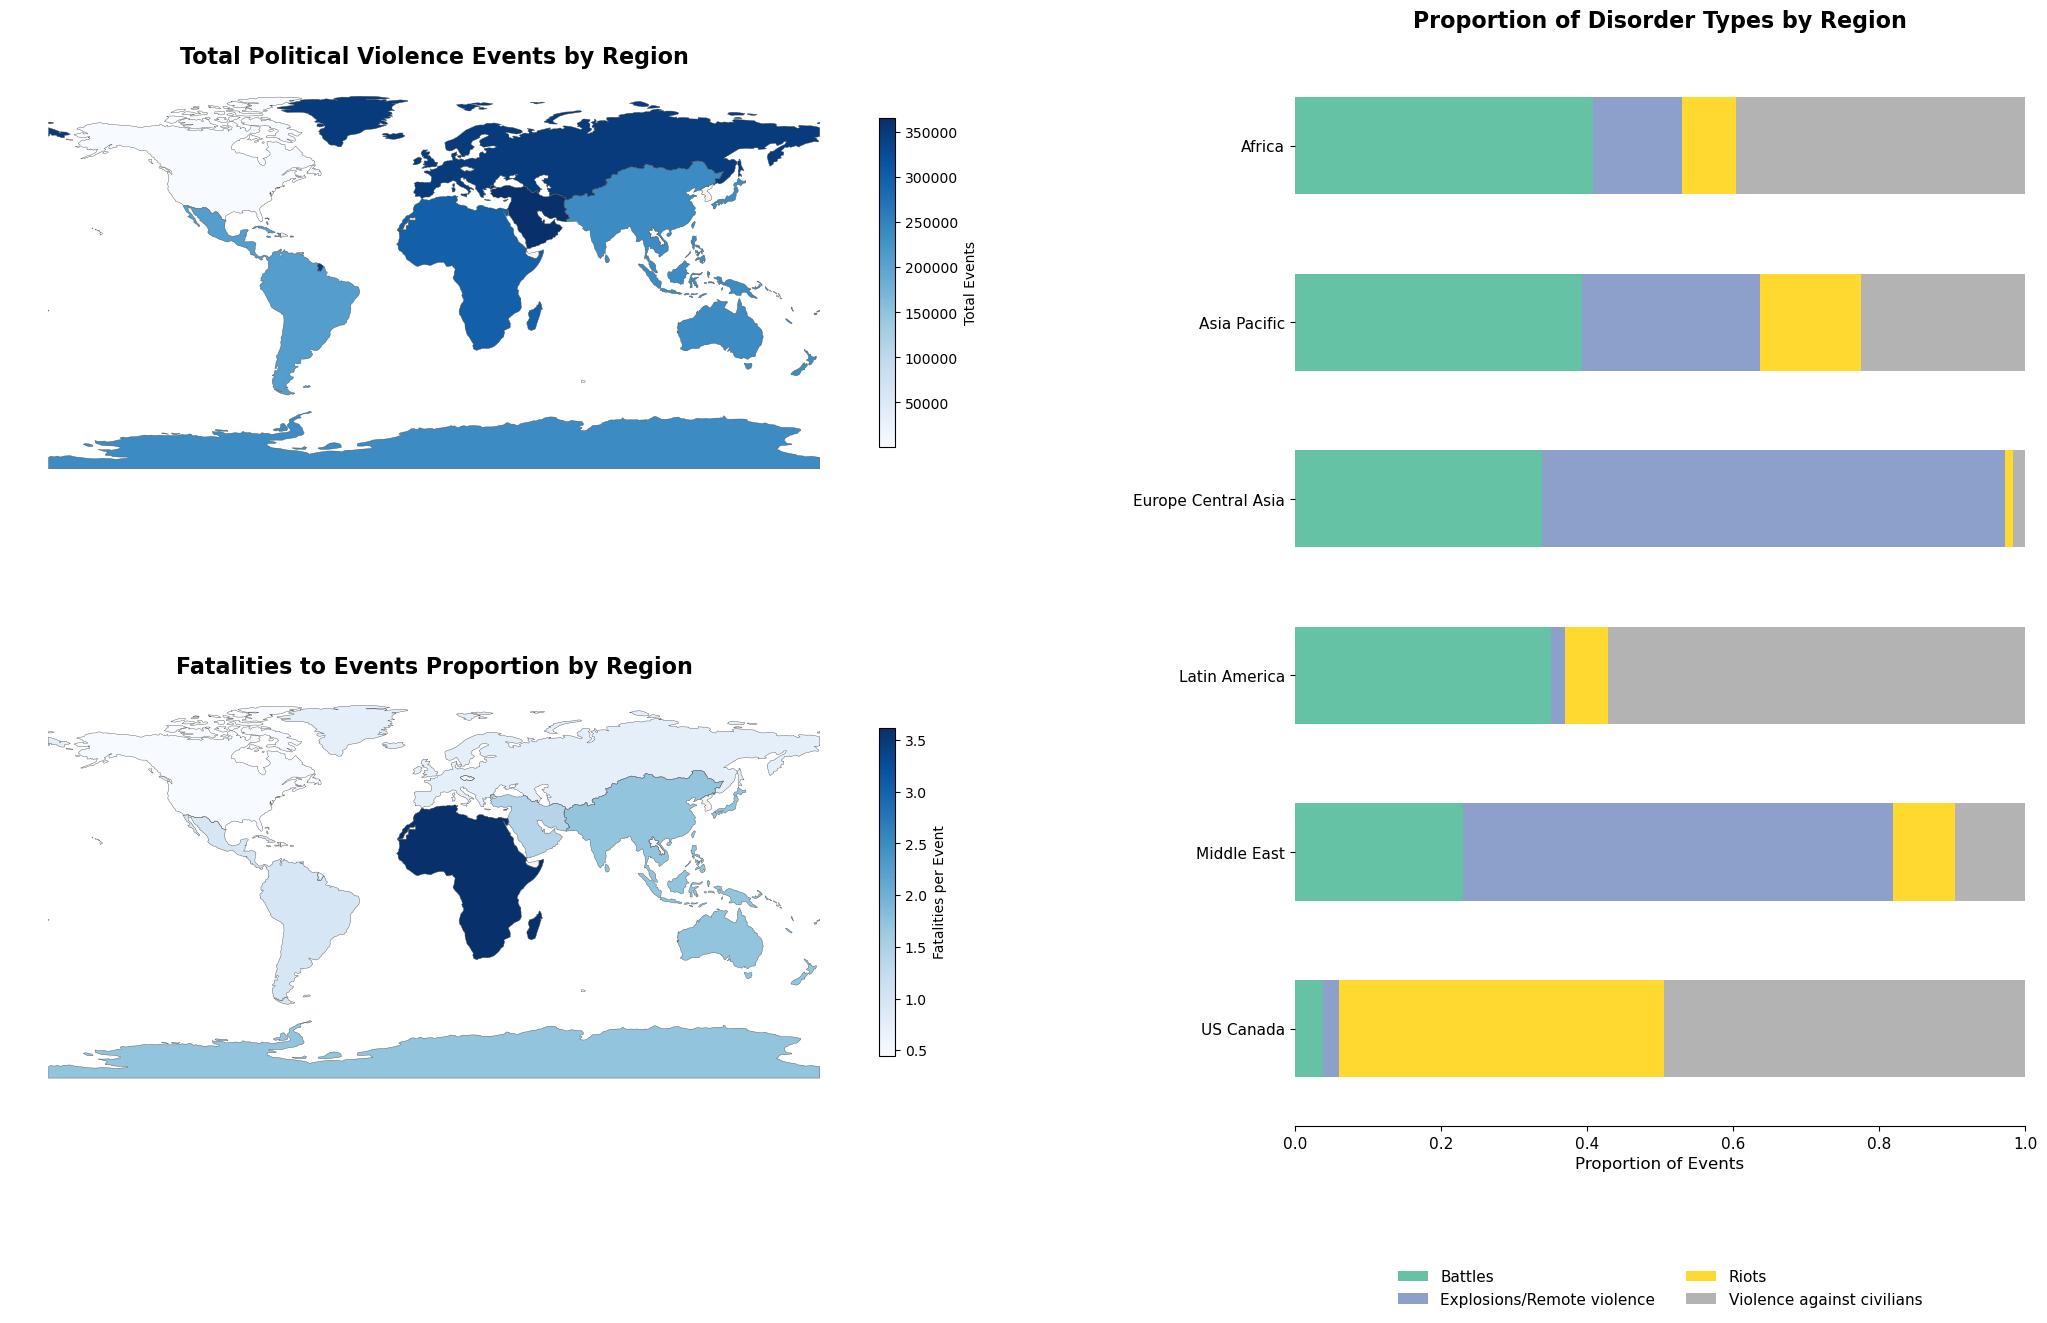

In [23]:
results = []
all_event_types = set()

for region, reg_data in data.items():
    pv_data = reg_data[reg_data["DISORDER_TYPE"] == "Political violence"]

    num_of_events = pv_data["EVENTS"].sum()
    fatalities_sum = pv_data["FATALITIES"].sum()
    ratio = fatalities_sum / num_of_events if num_of_events > 0 else 0

    results.append(
        {
            "Region": region,
            "Events": num_of_events,
            "Fatalities": fatalities_sum,
            "Fatalities_to_Events": ratio,
        }
    )
    all_event_types.update(pv_data["EVENT_TYPE"].dropna().unique())

summary_df = pd.DataFrame(results)
all_event_types = sorted(list(all_event_types))

proportions_data = []
for region, reg_data in data.items():
    pv_data = reg_data[reg_data["DISORDER_TYPE"] == "Political violence"]
    event_counts = pv_data.groupby("EVENT_TYPE")["EVENTS"].sum()
    total_events = event_counts.sum()

    region_props = {"Region": region}
    for et in all_event_types:
        if total_events > 0:
            region_props[et] = event_counts.get(et, 0) / total_events
        else:
            region_props[et] = 0.0
    proportions_data.append(region_props)

props_df = pd.DataFrame(proportions_data).set_index("Region")

regions_countries = {
    "Africa": [
        "Algeria", "Angola", "Benin", "Botswana", "British Indian Ocean Territory", "Burkina Faso", 
        "Burundi", "Cameroon", "Cape Verde", "Central African Republic", "Central African Rep.", 
        "Chad", "Comoros", "Democratic Republic of Congo", "Dem. Rep. Congo", "Djibouti", 
        "Egypt", "Equatorial Guinea", "Eq. Guinea", "Eritrea", "Ethiopia", "Gabon", "Gambia", 
        "Ghana", "Guinea", "Guinea-Bissau", "Ivory Coast", "Côte d'Ivoire", "Kenya", "Lesotho", 
        "Liberia", "Libya", "Madagascar", "Malawi", "Mali", "Mauritania", "Mauritius", "Mayotte", 
        "Morocco", "Mozambique", "Namibia", "Niger", "Nigeria", "Republic of Congo", "Congo", 
        "Reunion", "Rwanda", "Saint Helena, Ascension and Tristan da Cunha", "Sao Tome and Principe", 
        "Senegal", "Seychelles", "Sierra Leone", "Somalia", "South Africa", "South Sudan", "S. Sudan", 
        "Sudan", "Tanzania", "Togo", "Tunisia", "Uganda", "Zambia", "Zimbabwe", "eSwatini", "Swaziland"
    ],
    "Asia Pacific": [
        "Afghanistan", "American Samoa", "Antarctica", "Australia", "Bangladesh", "Bhutan", "Brunei", 
        "Cambodia", "China", "Christmas Island", "Cook Islands", "East Timor", "Timor-Leste", "Fiji", 
        "French Polynesia", "Guam", "India", "Indonesia", "Japan", "Kiribati", "Laos", "Malaysia", 
        "Maldives", "Marshall Islands", "Micronesia", "Mongolia", "Myanmar", "Nauru", "Nepal", 
        "New Caledonia", "New Zealand", "Niue", "North Korea", "Northern Mariana Islands", "Pakistan", 
        "Palau", "Papua New Guinea", "Philippines", "Samoa", "Singapore", "Solomon Islands", 
        "South Korea", "Sri Lanka", "Taiwan", "Thailand", "Tokelau", "Tonga", "Tuvalu", "Vanuatu", 
        "Vietnam", "Wallis and Futuna"
    ],
    "Europe Central Asia": [
        "Akrotiri and Dhekelia", "Albania", "Andorra", "Armenia", "Austria", "Azerbaijan", 
        "Bailiwick of Guernsey", "Bailiwick of Jersey", "Belarus", "Belgium", "Bosnia and Herzegovina", 
        "Bosnia and Herz.", "Bulgaria", "Croatia", "Cyprus", "Czech Republic", "Czechia", "Denmark", 
        "Estonia", "Faroe Islands", "Finland", "France", "Georgia", "Germany", "Gibraltar", "Greece", 
        "Greenland", "Hungary", "Iceland", "Ireland", "Isle of Man", "Italy", "Kazakhstan", "Kosovo", 
        "Kyrgyzstan", "Latvia", "Liechtenstein", "Lithuania", "Luxembourg", "Malta", "Moldova", 
        "Monaco", "Montenegro", "Netherlands", "North Macedonia", "Macedonia", "Norway", "Poland", 
        "Portugal", "Romania", "Russia", "San Marino", "Serbia", "Slovakia", "Slovenia", "Spain", 
        "Sweden", "Switzerland", "Tajikistan", "Turkmenistan", "Ukraine", "United Kingdom", 
        "Uzbekistan", "Vatican City"
    ],
    "Latin America": [
        "Anguilla", "Antigua and Barbuda", "Argentina", "Aruba", "Bahamas", "Barbados", "Belize", 
        "Bolivia", "Brazil", "British Virgin Islands", "Caribbean Netherlands", "Cayman Islands", 
        "Chile", "Colombia", "Costa Rica", "Cuba", "Curacao", "Dominica", "Dominican Republic", 
        "Dom. Rep.", "Ecuador", "El Salvador", "Falkland Islands", "Falkland Is.", "French Guiana", 
        "Grenada", "Guadeloupe", "Guatemala", "Guyana", "Haiti", "Honduras", "Jamaica", "Martinique", 
        "Mexico", "Montserrat", "Nicaragua", "Panama", "Paraguay", "Peru", "Puerto Rico", 
        "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines", "Saint-Barthelemy", 
        "Saint-Martin", "Sint Maarten", "Suriname", "Trinidad and Tobago", "Turks and Caicos Islands", 
        "Uruguay", "Venezuela", "Virgin Islands, U.S."
    ],
    "Middle East": [
        "Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon", "Oman", "Palestine", 
        "Qatar", "Saudi Arabia", "Syria", "Turkey", "United Arab Emirates", "Yemen"
    ],
    "US Canada": [
        "Bermuda", "Canada", "Saint Pierre and Miquelon", "United States", "United States of America"
    ],
}

country_to_region = {
    country.lower(): region
    for region, countries in regions_countries.items()
    for country in countries
}

country_to_region["united states of america"] = "US Canada"
country_to_region["s. sudan"] = "Africa"
country_to_region["dem. rep. congo"] = "Africa"
country_to_region["central african rep."] = "Africa"
country_to_region["eq. guinea"] = "Africa"
country_to_region["cote d'ivoire"] = "Africa"
country_to_region["bosnia and herz."] = "Europe Central Asia"
country_to_region["czechia"] = "Europe Central Asia"
country_to_region["falkland is."] = "Latin America"
country_to_region["dom. rep."] = "Latin America"

url = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)
world.columns = world.columns.str.lower()

world["Region"] = world["name"].apply(
    lambda x: country_to_region.get(str(x).strip().lower())
)
world["Region"] = world["Region"].fillna("Other")

world["geometry"] = world["geometry"].buffer(0)
world_regions = world.dissolve(by="Region").reset_index()

world_regions["geometry"] = world_regions["geometry"].buffer(0.01).buffer(-0.01)

merged_map_data = world_regions.merge(summary_df, on="Region", how="left")

fig = plt.figure(figsize=(26, 14))
gs = gridspec.GridSpec(
    2, 2, figure=fig, width_ratios=[3.5, 2.5], hspace=0.30, wspace=0.30
)

ax_map1 = fig.add_subplot(gs[0, 0])
ax_map1.set_title(
    "Total Political Violence Events by Region",
    fontsize=16,
    fontweight="bold",
    pad=10,
)

world_regions.plot(ax=ax_map1, color="#f4f4f4", edgecolor="none")

merged_map_data.dropna(subset=["Events"]).plot(
    column="Events",
    cmap="Blues",
    linewidth=0,
    ax=ax_map1,
    edgecolor="none",
    legend=True,
    legend_kwds={
        "label": "Total Events",
        "orientation": "vertical",
        "pad": 0.02,
        "shrink": 0.7,
    },
)

world_regions.plot(ax=ax_map1, facecolor="none", edgecolor="#555555", linewidth=0.3)
ax_map1.axis("off")


ax_map2 = fig.add_subplot(gs[1, 0])
ax_map2.set_title(
    "Fatalities to Events Proportion by Region",
    fontsize=16,
    fontweight="bold",
    pad=10,
)

world_regions.plot(ax=ax_map2, color="#f4f4f4", edgecolor="none")

merged_map_data.dropna(subset=["Fatalities_to_Events"]).plot(
    column="Fatalities_to_Events",
    cmap="Blues",
    linewidth=0,
    ax=ax_map2,
    edgecolor="none",
    legend=True,
    legend_kwds={
        "label": "Fatalities per Event",
        "orientation": "vertical",
        "pad": 0.02,
        "shrink": 0.7,
    },
)

world_regions.plot(ax=ax_map2, facecolor="none", edgecolor="#555555", linewidth=0.3)
ax_map2.axis("off")


ax_bar = fig.add_subplot(gs[:, 1])
ax_bar.set_title(
    "Proportion of Disorder Types by Region",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

props_df_sorted = props_df.iloc[::-1]

colors = plt.cm.get_cmap("Set2", len(all_event_types))

lefts = pd.Series(0.0, index=props_df_sorted.index)

for idx, event_type in enumerate(all_event_types):
    ax_bar.barh(
        props_df_sorted.index,
        props_df_sorted[event_type],
        left=lefts,
        label=event_type,
        color=colors(idx),
        height=0.55,
    )
    lefts += props_df_sorted[event_type]

ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.spines["left"].set_visible(False)
ax_bar.set_xlabel("Proportion of Events", fontsize=12)
ax_bar.set_xlim(0, 1.0)
ax_bar.tick_params(axis="both", which="major", labelsize=11)

ax_bar.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_21184/445473659.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("Set2", len(all_event_types))
/tmp/ipykernel_21184/445473659.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


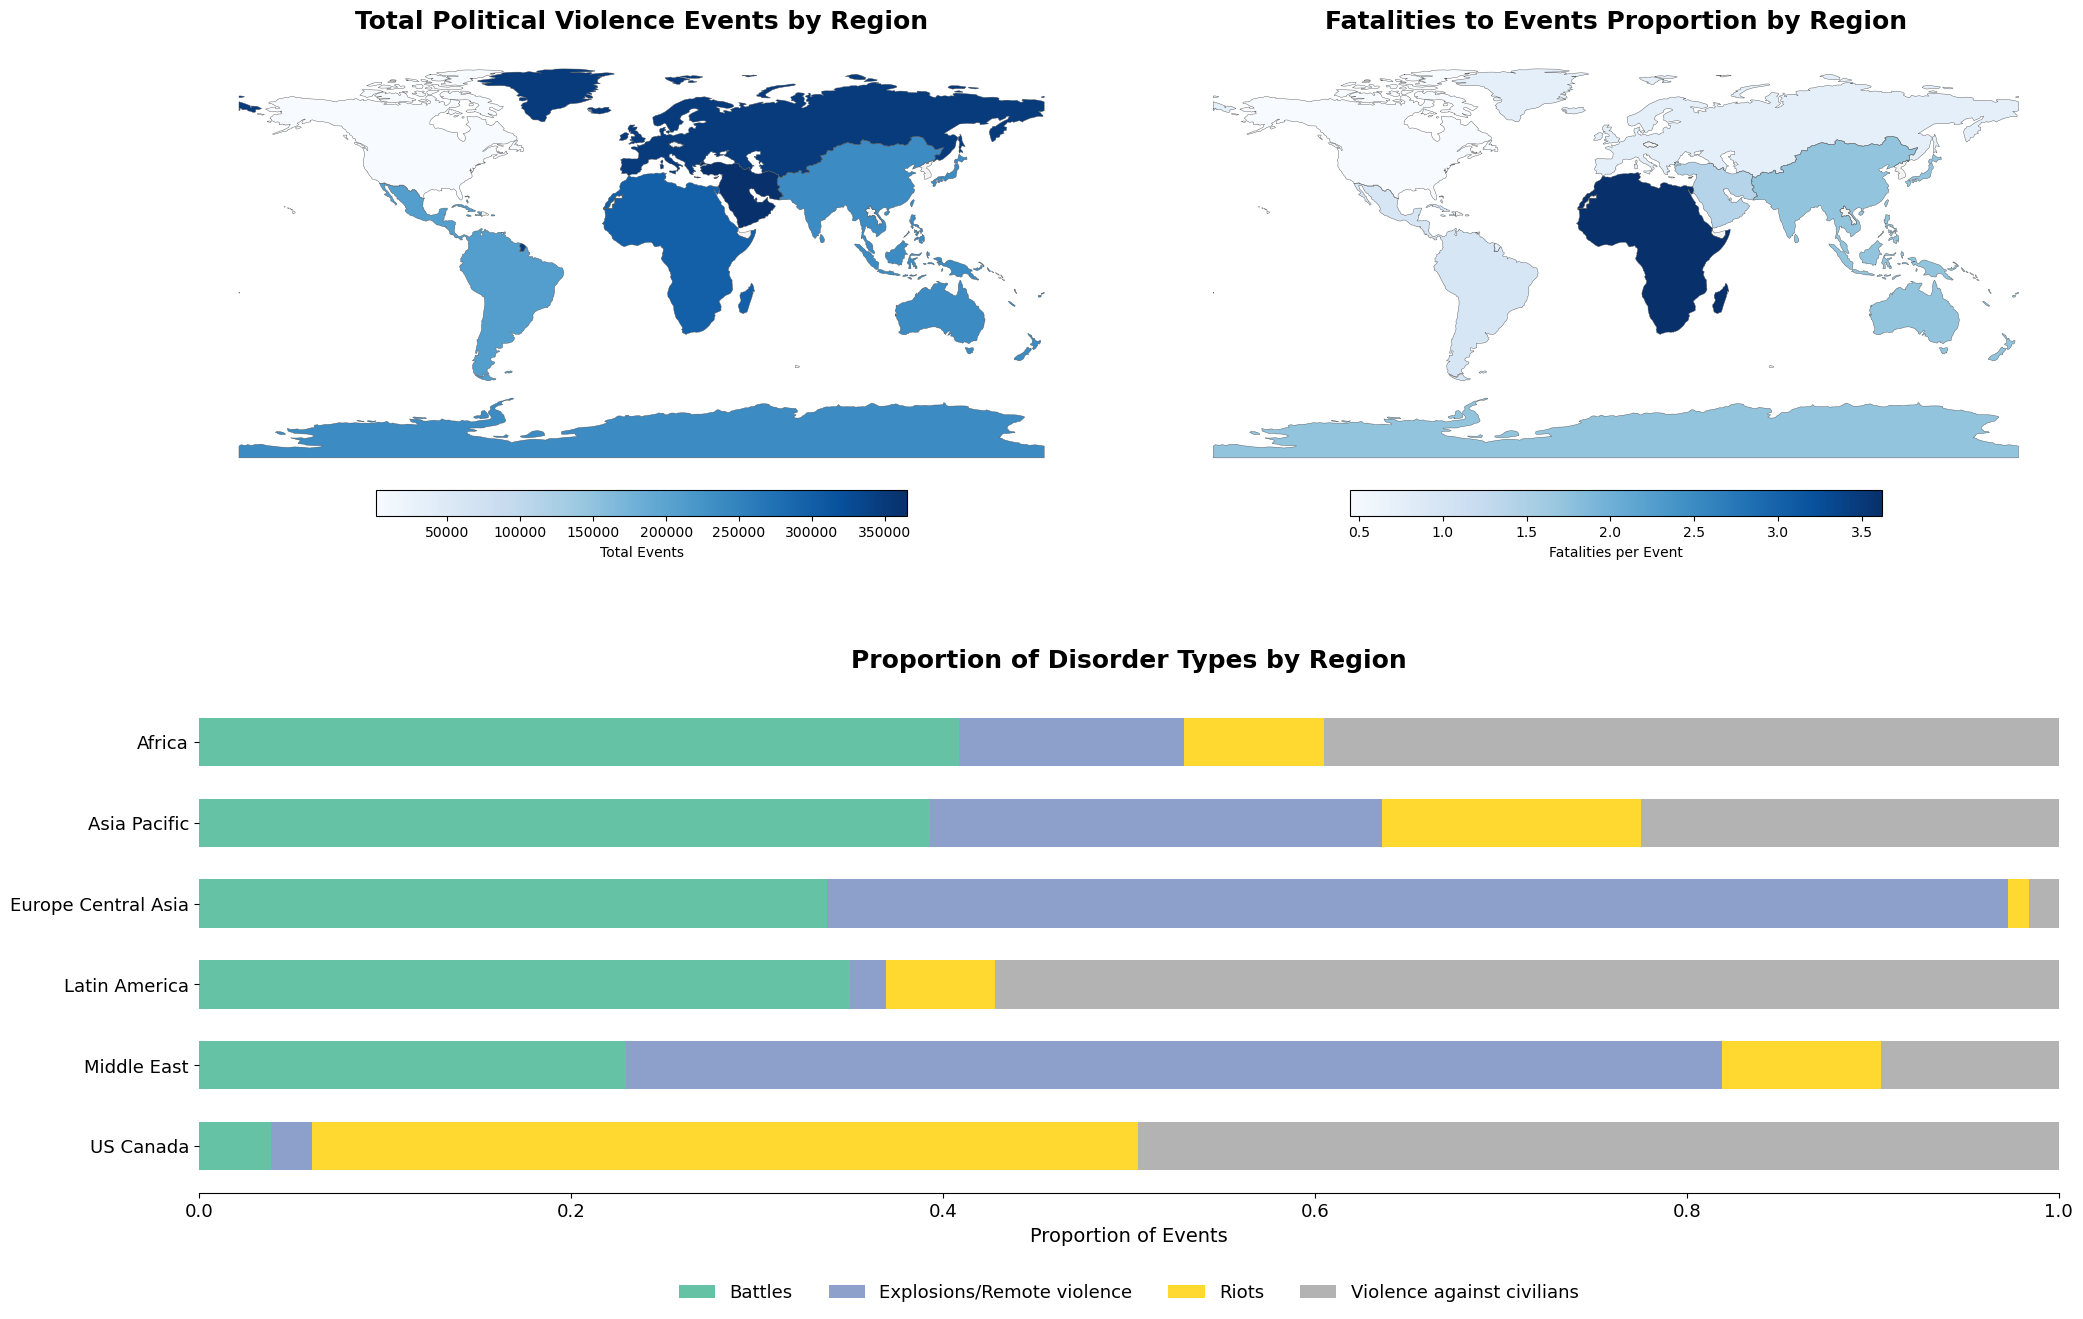

In [24]:
fig = plt.figure(figsize=(24, 16))

gs = gridspec.GridSpec(
    2, 2, figure=fig, 
    height_ratios=[1, 0.8], 
    hspace=0.2, 
    wspace=0.1
)

ax_map1 = fig.add_subplot(gs[0, 0])
ax_map1.set_title("Total Political Violence Events by Region", fontsize=18, fontweight="bold", pad=15)

world_regions.plot(ax=ax_map1, color="#f4f4f4", edgecolor="none")
merged_map_data.dropna(subset=["Events"]).plot(
    column="Events",
    cmap="Blues",
    ax=ax_map1,
    legend=True,
    legend_kwds={
        "label": "Total Events",
        "orientation": "horizontal",
        "pad": 0.02,
        "shrink": 0.6,
    },
)
world_regions.plot(ax=ax_map1, facecolor="none", edgecolor="#555555", linewidth=0.3)
ax_map1.axis("off")


ax_map2 = fig.add_subplot(gs[0, 1])
ax_map2.set_title("Fatalities to Events Proportion by Region", fontsize=18, fontweight="bold", pad=15)

world_regions.plot(ax=ax_map2, color="#f4f4f4", edgecolor="none")
merged_map_data.dropna(subset=["Fatalities_to_Events"]).plot(
    column="Fatalities_to_Events",
    cmap="Blues",
    ax=ax_map2,
    legend=True,
    legend_kwds={
        "label": "Fatalities per Event",
        "orientation": "horizontal",
        "pad": 0.02,
        "shrink": 0.6,
    },
)
world_regions.plot(ax=ax_map2, facecolor="none", edgecolor="#555555", linewidth=0.3)
ax_map2.axis("off")


ax_bar = fig.add_subplot(gs[1, :])
ax_bar.set_title("Proportion of Disorder Types by Region", fontsize=18, fontweight="bold", pad=20)

props_df_sorted = props_df.iloc[::-1]
colors = plt.cm.get_cmap("Set2", len(all_event_types))
lefts = pd.Series(0.0, index=props_df_sorted.index)

for idx, event_type in enumerate(all_event_types):
    ax_bar.barh(
        props_df_sorted.index,
        props_df_sorted[event_type],
        left=lefts,
        label=event_type,
        color=colors(idx),
        height=0.6,
    )
    lefts += props_df_sorted[event_type]

ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.spines["left"].set_visible(False)
ax_bar.set_xlabel("Proportion of Events", fontsize=14)
ax_bar.set_xlim(0, 1.0)
ax_bar.tick_params(axis="both", which="major", labelsize=13)

ax_bar.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(all_event_types),
    frameon=False,
    fontsize=13,
)

plt.tight_layout()
plt.show()

In [27]:
region_countries = {k: [] for k in data.keys()}

for region, reg_data in data.items():
    region_countries[region].extend(reg_data['COUNTRY'].unique().tolist())

In [28]:
civ_fat = pd.read_excel('conflict data/number_of_reported_civilian_fatalities_by_country-year_as-of-06Mar2026.xlsx')
fat = pd.read_excel('conflict data/number_of_reported_fatalities_by_country-year_as-of-06Mar2026.xlsx')

region_fat = {}

for region in data.keys():
    civilian_fat = civ_fat[civ_fat['COUNTRY'].isin(region_countries[region])]['FATALITIES'].sum()
    non_civilian_fat = fat[fat['COUNTRY'].isin(region_countries[region])]['FATALITIES'].sum()
    
    region_fat[region] = {
        'Civilian': civilian_fat,
        'Non Civilian': non_civilian_fat
    }
    
region_fat = pd.DataFrame(region_fat)

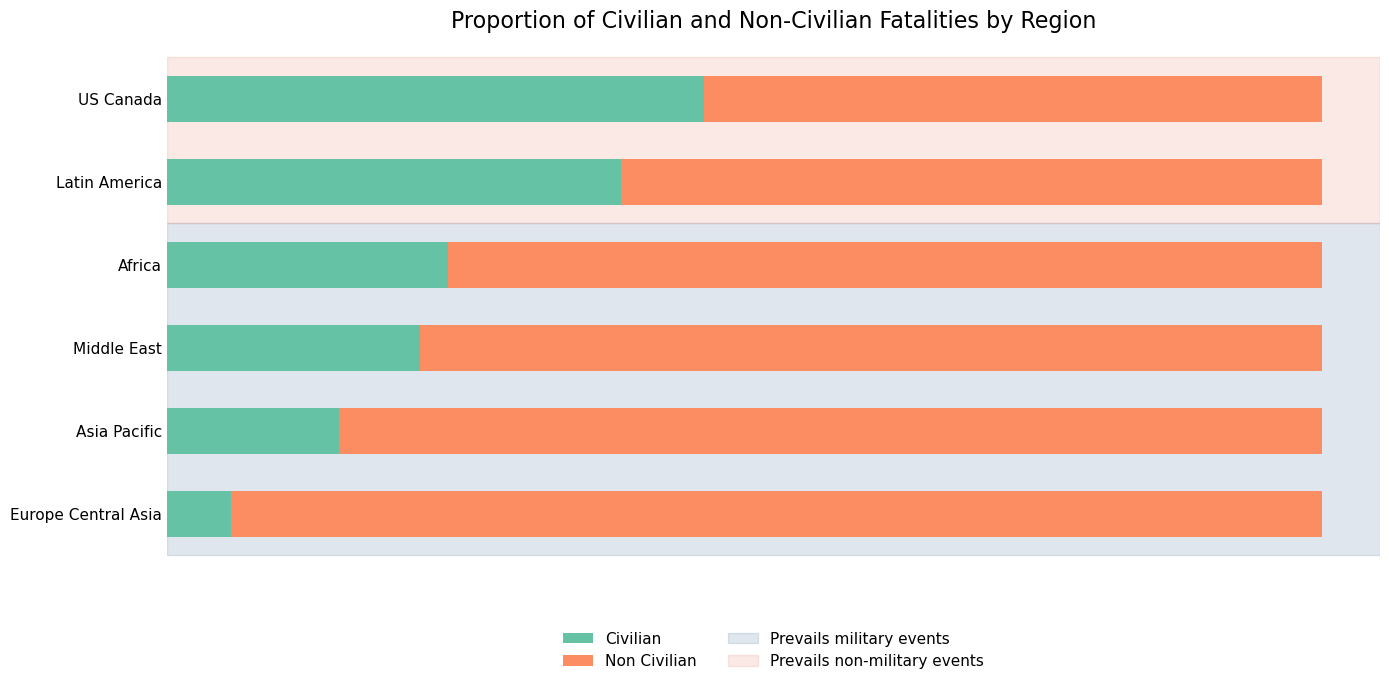

In [29]:
military_prevails = props_df_sorted[
    props_df_sorted[["Battles", "Explosions/Remote violence"]].sum(axis=1) > 0.5
]
group_military = military_prevails.index.tolist()
group_non_military = list(set(data.keys()).difference(group_military))

region_fat_prop = (region_fat / region_fat.sum()).T
df_sorted = region_fat_prop.sort_values(by="Civilian", ascending=True)

df_to_plot = df_sorted[["Civilian", "Non Civilian"]]

fig, ax = plt.subplots(figsize=(14, 7))

cmap = plt.get_cmap("Set2")
ax_colors = [cmap(0), cmap(1)]

df_to_plot.plot.barh(
    ax=ax,
    stacked=True,
    color=ax_colors,
    edgecolor="none",
    width=0.55,
    zorder=3,
)

ax.set_title(
    "Proportion of Civilian and Non-Civilian Fatalities by Region",
    fontsize=16,
    pad=20,
)

ax.xaxis.set_visible(False)

def shade_group(regions, bg_color):
    pos = [i for i, r in enumerate(df_to_plot.index) if r in regions]
    if pos:
        y_min, y_max = min(pos) - 0.5, max(pos) + 0.5
        ax.axhspan(y_min, y_max, color=bg_color, alpha=0.15, zorder=1)


shade_group(group_military, "#2b5c8f")
shade_group(group_non_military, "#e06d53")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(axis="both", which="both", length=0, labelsize=11)

bar_handles, bar_labels = ax.get_legend_handles_labels()

shade_handles = [
    mpatches.Patch(color="#2b5c8f", alpha=0.15, label="Prevails military events"),
    mpatches.Patch(
        color="#e06d53", alpha=0.15, label="Prevails non-military events"
    ),
]

all_handles = bar_handles + shade_handles

ax.legend(
    handles=all_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
)

plt.tight_layout()
plt.show()

In [36]:
fig = go.Figure()

buttons = []
trace_counter = 0
continents = list(data.keys())

total_traces = sum(len(data[c]['EVENT_TYPE'].unique()) for c in continents)

for i, continent in enumerate(continents):
    df = data[continent]
    
    processed_df = (
        df.set_index('WEEK')
        .sort_index()
        .groupby('EVENT_TYPE')
        .resample('YE')['FATALITIES']
        .sum()
        .unstack(0)
        .fillna(0)
    )
    
    num_event_types = len(processed_df.columns)
    
    sub_event_summary = (
        df.assign(YEAR=df['WEEK'].dt.year)
        .groupby(['YEAR', 'EVENT_TYPE', 'SUB_EVENT_TYPE'])['FATALITIES']
        .sum()
        .reset_index()
        .sort_values(['YEAR', 'EVENT_TYPE', 'FATALITIES'], ascending=[True, True, False])
    )

    for event_type in processed_df.columns:
        years = processed_df.index.year
        y_values = processed_df[event_type]
        
        hover_labels = []
        for year in years:
            subs = sub_event_summary[
                (sub_event_summary['YEAR'] == year) & 
                (sub_event_summary['EVENT_TYPE'] == event_type) &
                (sub_event_summary['FATALITIES'] > 0)
            ]
            
            if not subs.empty:
                sub_text = "<br>".join([f"• {row.SUB_EVENT_TYPE}: {int(row.FATALITIES)}" for row in subs.itertuples()])
                hover_labels.append(f"<b>{event_type} ({year})</b><br>{sub_text}")
            else:
                hover_labels.append(f"<b>{event_type} ({year})</b><br>No data")

        fig.add_trace(
            go.Bar(
                x=years,
                y=y_values,
                name=event_type,
                visible=(i == 0),
                hovertext=hover_labels,
                hoverinfo="text"
            )
        )
    
    visibility = [False] * total_traces
    for j in range(trace_counter, trace_counter + num_event_types):
        visibility[j] = True
        
    buttons.append(dict(
        label=continent,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Number of fatalities in {continent}"}]
    ))
    
    trace_counter += num_event_types

fig.update_layout(
    template="plotly_white",
    colorway=px.colors.qualitative.Set2,
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "showactive": True,
        "x": 1.03,
        "y": 0.40,
        "xanchor": "left"
    }],
    barmode='stack', 
    xaxis_title="Year",
    yaxis_title="Total Fatalities",
    legend_title="Event Type",
    title=f"Number of fatalities in {continents[0]}",
    hoverlabel=dict(align="left")
)

fig.update_xaxes(type='category')

fig.show()